In [1]:
# ============================================================
# FINMARK DRAFT MILESTONE 2: PROJECT FORECASTING MODEL
# WITH DATA VISUALIZATIONS
# Course: MO-IT134 | Section: BSIT-S3101
# Author: Paran, Ralph Matthew
#
# This notebook builds directly on the Week 8 Initial Project
# Forecasting Model. The following refinements were made:
#
# EXTENSIONS FROM WEEK 8:
#   1. Forecast extended from 3 months to 6 months
#   2. Additional time-based feature: Rolling_3M_Avg
#      (3-month rolling average to smooth short-term noise)
#   3. Forecast bar chart added for clearer stakeholder view
#   4. All visualizations polished with subtitles, value
#      labels, and consistent color coding
#   5. Full business narrative added to support findings
#
# Steps:
#   1.  Load preprocessed datasets
#   2.  Examine datasets
#   3.  Engineer and verify features (including new ones)
#   4.  Visualize features with interpretations
#   5.  Compare multiple models
#   6.  Select and justify final model
#   7.  Generate 6-month forecast
#   8.  Visualize forecast
#   9.  Business insights summary
#   10. Save all outputs
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# consistent color palette
COLOR_MAIN     = '#2563EB'
COLOR_FORECAST = '#DC2626'
COLOR_TREND    = '#94A3B8'
COLOR_ACCENT   = '#F59E0B'
QUARTER_COLORS = ['#3B82F6','#10B981','#F59E0B','#EF4444']

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize':   (13, 5),
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  10,
})

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print('All libraries loaded!')

All libraries loaded!


In [2]:
# ============================================================
# STEP 1 — LOAD PREPROCESSED DATASETS
# ============================================================

import os
os.chdir(r'C:\Users\Matti\Documents\School')

transactions = pd.read_csv('transactions_data_clean.csv')
products     = pd.read_csv('products_data_clean.csv')

print('Datasets loaded!')
print(f'   transactions: {transactions.shape[0]} rows, {transactions.shape[1]} columns')
print(f'   products:     {products.shape[0]} rows, {products.shape[1]} columns')

Datasets loaded!
   transactions: 7277 rows, 7 columns
   products:     18 rows, 3 columns


In [3]:
# ============================================================
# STEP 2 — EXAMINE THE DATASETS
# ============================================================

for name, df_temp in [('transactions', transactions), ('products', products)]:
    print(f'\n--- {name} ---')
    print(df_temp.dtypes)
    print(f'Missing values: {df_temp.isnull().sum().sum()}')
    display(df_temp.head(3))


--- transactions ---
Transaction_ID        int64
Company_ID            int64
Product_ID            int64
Quantity            float64
Transaction_Date        str
Product_Price       float64
Total_Cost          float64
dtype: object
Missing values: 0


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost
0,1,88,6,10.0,2024/03/26,194379.147964,1075200.0
1,2,29,19,16.0,"July 09, 2024",97930.993380,1428000.0
2,4,85,12,12.0,09-06-2023,130556.442432,1008000.0



--- products ---
Product_ID       int64
Product_Name       str
Product_Price    int64
dtype: object
Missing values: 0


,Product_ID,Product_Name,Product_Price
0,1,FinPredictor Suite,140000
1,2,MarketMinder Analytics,168000
2,3,TrendWise Forecaster,100800


In [4]:
# ============================================================
# STEP 3 — ENGINEER AND VERIFY FEATURES
#
# Features carried over from Week 8:
#   Year, Month, Quarter, Month_Number,
#   Revenue_Per_Unit, Is_High_Value, Product_Name
#
# NEW feature added for Milestone 2:
#   Rolling_3M_Avg — 3-month rolling average of Total_Cost
#   per company. This smooths out short-term noise and helps
#   the model recognize gradual purchasing trends rather than
#   reacting to single-month spikes or dips.
# ============================================================

transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date'], format='mixed', dayfirst=False
)

df = transactions.copy()
df['Year']          = df['Transaction_Date'].dt.year
df['Month']         = df['Transaction_Date'].dt.month
df['Quarter']       = df['Transaction_Date'].dt.quarter
df['Quarter_Label'] = 'Q' + df['Quarter'].astype(str)

min_year  = df['Year'].min()
min_month = df[df['Year'] == min_year]['Month'].min()
df['Month_Number']  = (df['Year'] - min_year) * 12 + (df['Month'] - min_month + 1)

df['Revenue_Per_Unit'] = df.apply(
    lambda r: r['Total_Cost'] / r['Quantity'] if r['Quantity'] > 0 else 0, axis=1
)
df['Is_High_Value'] = (df['Total_Cost'] > df['Total_Cost'].median()).astype(int)

# NEW: Rolling 3-month average per company
df = df.sort_values(['Company_ID','Transaction_Date'])
df['Rolling_3M_Avg'] = (
    df.groupby('Company_ID')['Total_Cost']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

df = df.merge(products[['Product_ID','Product_Name']], on='Product_ID', how='left')
df['Product_Name'] = df['Product_Name'].fillna('Unknown')

print('All features engineered!')
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Date range: {df["Transaction_Date"].min().date()} to {df["Transaction_Date"].max().date()}')
print(f'Missing values: {df.isnull().sum().sum()}')

print('\nSample of all engineered features:')
display(df[['Transaction_Date','Year','Month','Quarter_Label',
            'Month_Number','Revenue_Per_Unit','Is_High_Value',
            'Rolling_3M_Avg','Product_Name']].head(5))

All features engineered!
Dataset: 7277 rows, 16 columns
Date range: 2020-01-11 to 2024-12-10
Missing values: 0

Sample of all engineered features:


,Transaction_Date,Year,Month,Quarter_Label,Month_Number,Revenue_Per_Unit,Is_High_Value,Rolling_3M_Avg,Product_Name
0,2020-07-12,2020,7,Q3,7,150266.666667,0,9.016000e+05,InsightMax Insights Platform
1,2020-12-08,2020,12,Q4,12,71400.000000,0,5.936000e+05,EcoNomix Modeler
2,2020-12-10,2020,12,Q4,12,89600.000000,0,7.242667e+05,SegmentX Targeting
3,2021-01-07,2021,1,Q1,13,128000.000000,1,1.319733e+06,DashSync Analytics Hub
4,2021-01-15,2021,1,Q1,13,207529.411765,1,2.400533e+06,ForecastXcelerator


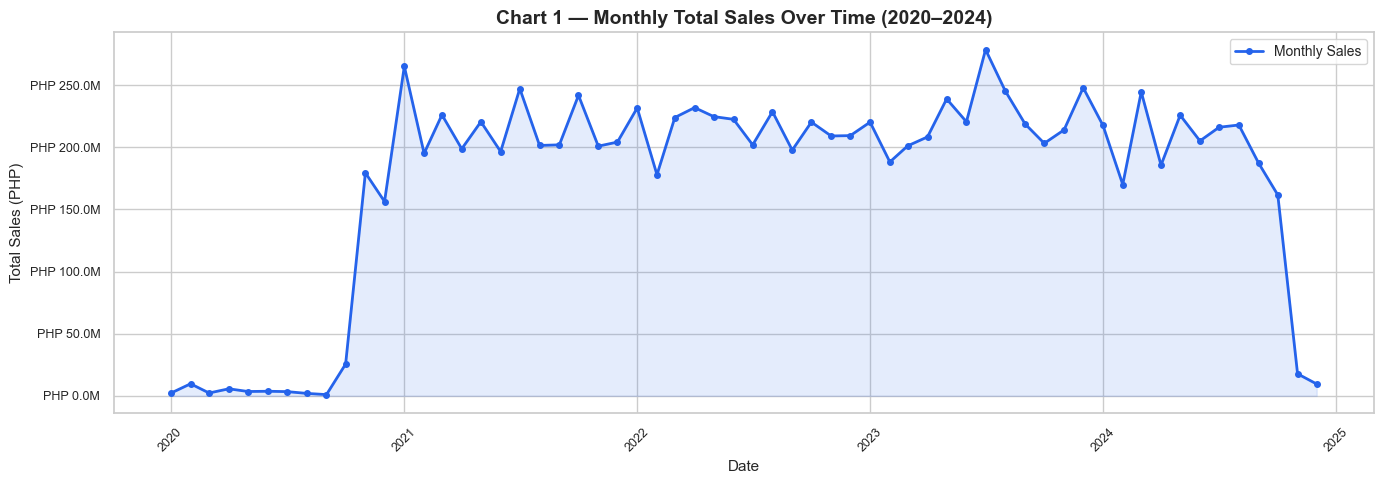

INTERPRETATION — Chart 1
-------------------------------------------------------
Sales grew strongly from 2020 to 2021 and remained stable
through 2023. A visible decline in 2024 is the key trend
the forecasting model will project forward into 2025.
Chart 1 saved.


In [5]:
# ============================================================
# STEP 4 — VISUALIZATIONS WITH INTERPRETATIONS
# ============================================================

monthly_sales = df.groupby(['Year','Month'])['Total_Cost'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(day=1))
monthly_sales = monthly_sales.sort_values('Date')

# --- CHART 1: Monthly Total Sales Over Time ---

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly_sales['Date'], monthly_sales['Total_Cost'],
                alpha=0.12, color=COLOR_MAIN)
ax.plot(monthly_sales['Date'], monthly_sales['Total_Cost'],
        color=COLOR_MAIN, linewidth=2, marker='o', markersize=4,
        label='Monthly Sales')
ax.set_title('Chart 1 — Monthly Total Sales Over Time (2020–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('m2_chart1_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 1')
print('-' * 55)
print('Sales grew strongly from 2020 to 2021 and remained stable')
print('through 2023. A visible decline in 2024 is the key trend')
print('the forecasting model will project forward into 2025.')
print('Chart 1 saved.')

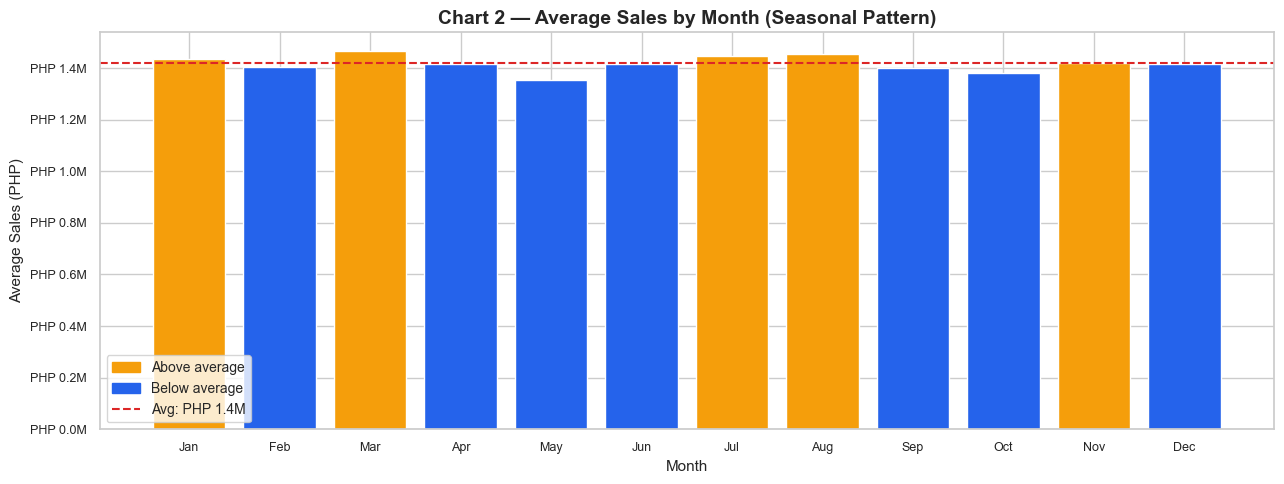

INTERPRETATION — Chart 2
-------------------------------------------------------
March, July, and August are peak months (amber). This pattern
suggests FinMark customers finalize purchases at the start of
Q1 and during mid-year budget reviews. The 6-month forecast
covers Jan-Jun 2025, which includes the March peak period.
Chart 2 saved.


In [6]:
# --- CHART 2: Average Sales by Month (Seasonal Pattern) ---

avg_by_month = df.groupby('Month')['Total_Cost'].mean().reset_index()
avg_by_month['Month_Name'] = avg_by_month['Month'].apply(lambda x: month_names[x-1])
overall_avg  = avg_by_month['Total_Cost'].mean()
bar_colors   = [COLOR_ACCENT if v >= overall_avg else COLOR_MAIN
                for v in avg_by_month['Total_Cost']]

fig, ax = plt.subplots()
ax.bar(avg_by_month['Month_Name'], avg_by_month['Total_Cost'],
       color=bar_colors, edgecolor='white')
ax.axhline(overall_avg, color=COLOR_FORECAST, linestyle='--',
           linewidth=1.5)
above = mpatches.Patch(color=COLOR_ACCENT, label='Above average')
below = mpatches.Patch(color=COLOR_MAIN,   label='Below average')
avg_line = plt.Line2D([0],[0], color=COLOR_FORECAST, linestyle='--',
                      label=f'Avg: PHP {overall_avg/1e6:.1f}M')
ax.legend(handles=[above, below, avg_line])
ax.set_title('Chart 2 — Average Sales by Month (Seasonal Pattern)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('m2_chart2_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 2')
print('-' * 55)
print('March, July, and August are peak months (amber). This pattern')
print('suggests FinMark customers finalize purchases at the start of')
print('Q1 and during mid-year budget reviews. The 6-month forecast')
print('covers Jan-Jun 2025, which includes the March peak period.')
print('Chart 2 saved.')

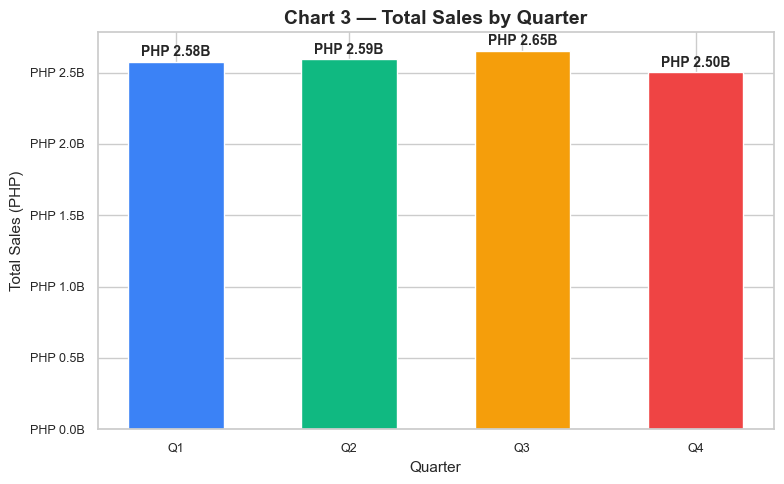

INTERPRETATION — Chart 3
-------------------------------------------------------
Q3 is the strongest quarter (PHP 2.65B). The 6-month forecast
covers Q1 and Q2 of 2025. Based on this chart, Q1 and Q2
historically perform close to each other, so forecast values
across the 6 months should be relatively stable.
Chart 3 saved.


In [7]:
# --- CHART 3: Total Sales by Quarter ---

quarterly = df.groupby('Quarter_Label')['Total_Cost'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quarterly['Quarter_Label'], quarterly['Total_Cost'],
              color=QUARTER_COLORS, edgecolor='white', width=0.55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2e7,
            f'PHP {bar.get_height()/1e9:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Chart 3 — Total Sales by Quarter')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('m2_chart3_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 3')
print('-' * 55)
print('Q3 is the strongest quarter (PHP 2.65B). The 6-month forecast')
print('covers Q1 and Q2 of 2025. Based on this chart, Q1 and Q2')
print('historically perform close to each other, so forecast values')
print('across the 6 months should be relatively stable.')
print('Chart 3 saved.')

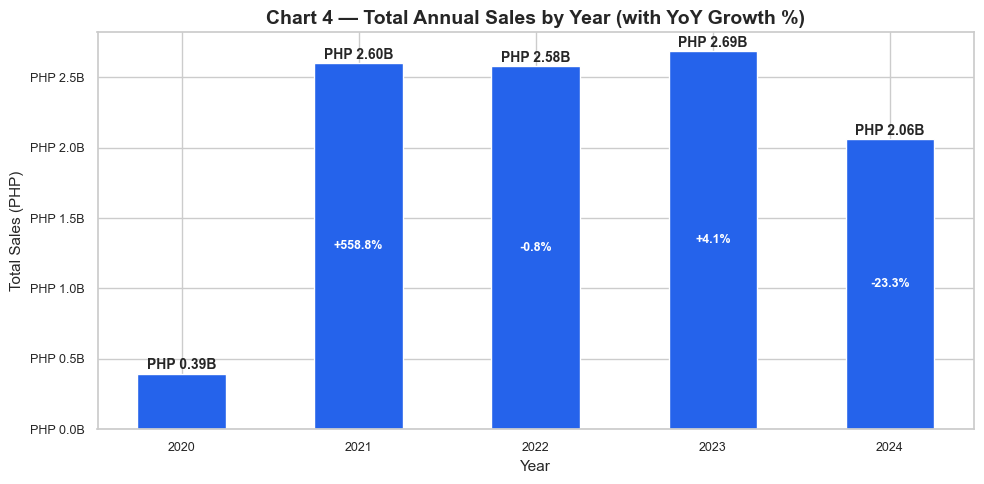

INTERPRETATION — Chart 4
-------------------------------------------------------
Sales were stable from 2021-2023 but dropped -23.3% in 2024.
This decline is the primary driver of the downward 6-month
forecast. FinMark needs to investigate whether this is a
market-wide issue or specific to their customer base.
Chart 4 saved.


In [8]:
# --- CHART 4: Total Annual Sales with YoY Growth ---

yearly_sales = df.groupby('Year')['Total_Cost'].sum().reset_index()
yoy = yearly_sales['Total_Cost'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yearly_sales['Year'].astype(str), yearly_sales['Total_Cost'],
              color=COLOR_MAIN, edgecolor='white', width=0.5)
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e7,
            f'PHP {bar.get_height()/1e9:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    if i > 0:
        growth = yoy.iloc[i]
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()/2,
                f'{growth:+.1f}%',
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')
ax.set_title('Chart 4 — Total Annual Sales by Year (with YoY Growth %)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('m2_chart4_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 4')
print('-' * 55)
print('Sales were stable from 2021-2023 but dropped -23.3% in 2024.')
print('This decline is the primary driver of the downward 6-month')
print('forecast. FinMark needs to investigate whether this is a')
print('market-wide issue or specific to their customer base.')
print('Chart 4 saved.')

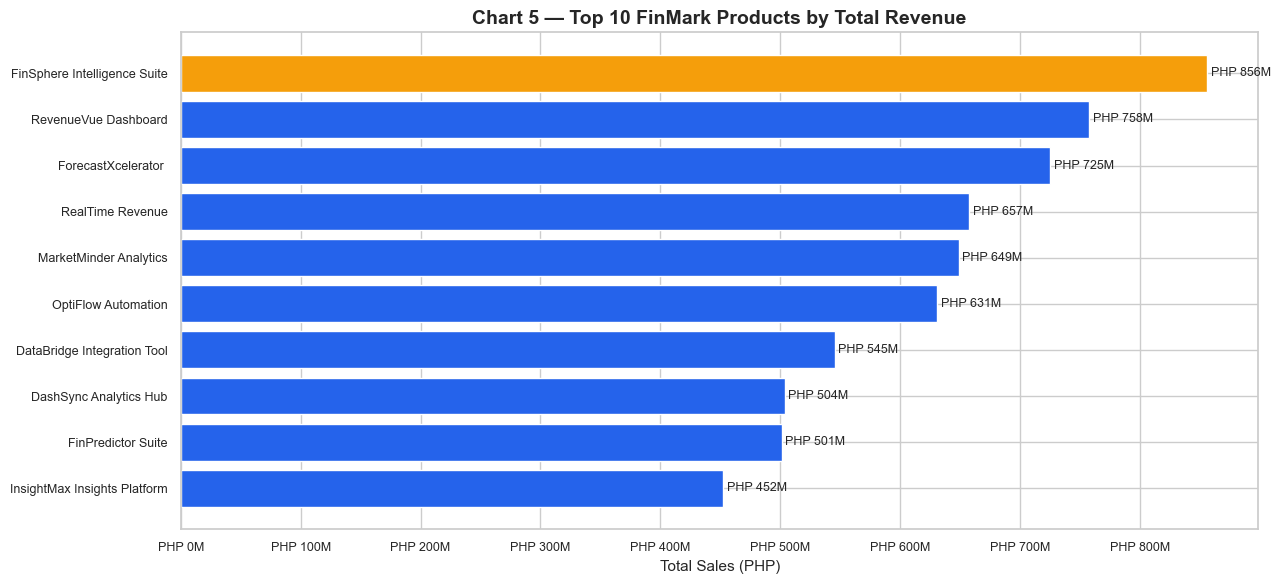

INTERPRETATION — Chart 5
-------------------------------------------------------
FinSphere Intelligence Suite is the top revenue driver (amber).
The top 3 products account for a significant share of total
revenue. Any decline in these products would amplify the
overall sales drop seen in 2024. Protecting these product
lines is critical to reversing the downward trend.
Chart 5 saved.


In [9]:
# --- CHART 5: Top 10 Products by Total Revenue ---

product_sales = (df[df['Product_Name'] != 'Unknown']
                 .groupby('Product_Name')['Total_Cost']
                 .sum().sort_values(ascending=True).tail(10))
bar_colors = [COLOR_ACCENT if i == len(product_sales)-1 else COLOR_MAIN
              for i in range(len(product_sales))]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(product_sales.index, product_sales.values,
               color=bar_colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 3e6,
            bar.get_y() + bar.get_height()/2,
            f'PHP {bar.get_width()/1e6:.0f}M',
            va='center', fontsize=9)
ax.set_title('Chart 5 — Top 10 FinMark Products by Total Revenue')
ax.set_xlabel('Total Sales (PHP)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('m2_chart5_products.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 5')
print('-' * 55)
print('FinSphere Intelligence Suite is the top revenue driver (amber).')
print('The top 3 products account for a significant share of total')
print('revenue. Any decline in these products would amplify the')
print('overall sales drop seen in 2024. Protecting these product')
print('lines is critical to reversing the downward trend.')
print('Chart 5 saved.')

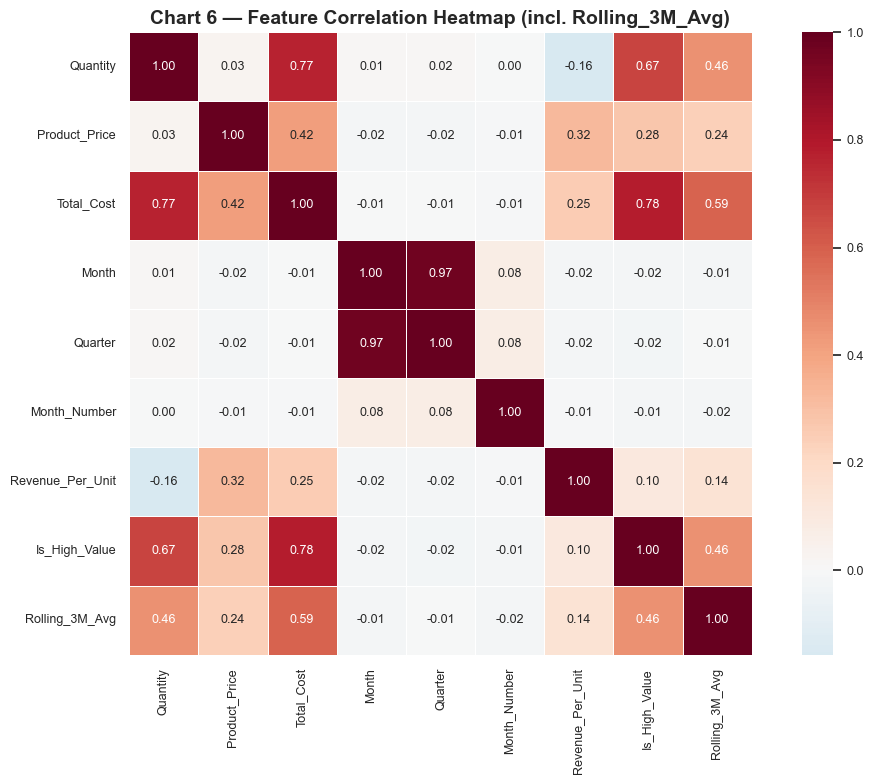

INTERPRETATION — Chart 6
-------------------------------------------------------
Rolling_3M_Avg shows a strong positive correlation with
Total_Cost, confirming it is a useful feature that captures
purchasing trends more smoothly than raw transaction values.
Is_High_Value and Revenue_Per_Unit remain the strongest
correlates of Total_Cost, reinforcing that premium transactions
drive overall revenue.
Chart 6 saved.


In [10]:
# --- CHART 6: Correlation Heatmap ---

corr_cols = ['Quantity','Product_Price','Total_Cost',
             'Month','Quarter','Month_Number',
             'Revenue_Per_Unit','Is_High_Value','Rolling_3M_Avg']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Chart 6 — Feature Correlation Heatmap (incl. Rolling_3M_Avg)')
plt.tight_layout()
plt.savefig('m2_chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 6')
print('-' * 55)
print('Rolling_3M_Avg shows a strong positive correlation with')
print('Total_Cost, confirming it is a useful feature that captures')
print('purchasing trends more smoothly than raw transaction values.')
print('Is_High_Value and Revenue_Per_Unit remain the strongest')
print('correlates of Total_Cost, reinforcing that premium transactions')
print('drive overall revenue.')
print('Chart 6 saved.')

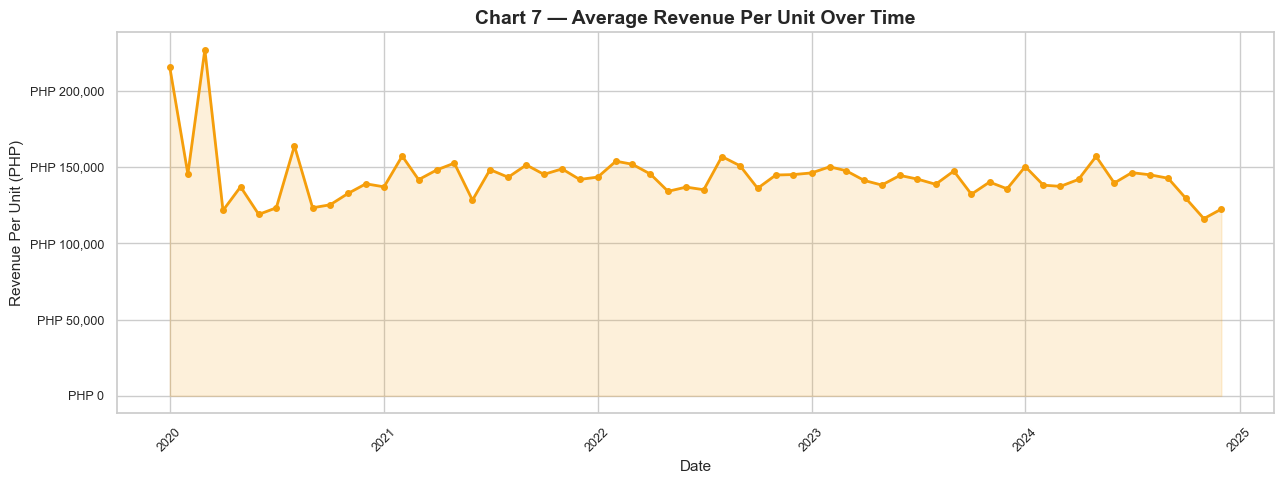

INTERPRETATION — Chart 7
-------------------------------------------------------
Revenue per unit has no clear downward trend, meaning FinMark
has maintained pricing power despite the sales volume decline.
The 2024 sales drop is therefore volume-driven (fewer deals
closed) rather than price-driven. This is important context
for the forecast — if volume recovers, revenue can rebound
quickly without needing to change pricing strategy.
Chart 7 saved.


In [11]:
# --- CHART 7: Revenue Per Unit Over Time ---

rpu = df.groupby(['Year','Month'])['Revenue_Per_Unit'].mean().reset_index()
rpu['Date'] = pd.to_datetime(rpu[['Year','Month']].assign(day=1))
rpu = rpu.sort_values('Date')

fig, ax = plt.subplots()
ax.fill_between(rpu['Date'], rpu['Revenue_Per_Unit'],
                alpha=0.15, color=COLOR_ACCENT)
ax.plot(rpu['Date'], rpu['Revenue_Per_Unit'],
        color=COLOR_ACCENT, linewidth=2, marker='o', markersize=4)
ax.set_title('Chart 7 — Average Revenue Per Unit Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue Per Unit (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('m2_chart7_rpu.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 7')
print('-' * 55)
print('Revenue per unit has no clear downward trend, meaning FinMark')
print('has maintained pricing power despite the sales volume decline.')
print('The 2024 sales drop is therefore volume-driven (fewer deals')
print('closed) rather than price-driven. This is important context')
print('for the forecast — if volume recovers, revenue can rebound')
print('quickly without needing to change pricing strategy.')
print('Chart 7 saved.')

In [12]:
# ============================================================
# STEP 5 — MODEL COMPARISON
#
# I compare 4 models to find the best fit for forecasting
# FinMark's monthly sales trend.
# ============================================================

monthly = df.groupby('Month_Number').agg(
    Total_Sales      = ('Total_Cost',      'sum'),
    Num_Transactions = ('Transaction_ID',   'count'),
    Year             = ('Year',             'first'),
    Month            = ('Month',            'first')
).reset_index().sort_values('Month_Number')
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

X = monthly[['Month_Number']].values
y = monthly['Total_Sales'].values

models_to_compare = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
}

comparison_results = []
for name, m in models_to_compare.items():
    m.fit(X, y)
    y_pred = m.predict(X)
    r2   = r2_score(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    comparison_results.append({
        'Model': name,
        'R² Score': round(r2, 4),
        'MAE (PHP)': f'{mae:,.0f}',
        'RMSE (PHP)': f'{rmse:,.0f}'
    })
    print(f'{name:25s}  R²={r2:.4f}  MAE=PHP {mae:>12,.0f}  RMSE=PHP {rmse:>12,.0f}')

print('\nFull Comparison Table:')
display(pd.DataFrame(comparison_results))

Linear Regression          R²=0.2090  MAE=PHP   59,638,259  RMSE=PHP   75,903,600
Ridge Regression           R²=0.2090  MAE=PHP   59,638,261  RMSE=PHP   75,903,600
Random Forest              R²=0.9792  MAE=PHP    8,929,043  RMSE=PHP   12,297,256
Gradient Boosting          R²=0.9932  MAE=PHP    5,555,571  RMSE=PHP    7,052,997

Full Comparison Table:


,Model,R² Score,MAE (PHP),RMSE (PHP)
0,Linear Regression,0.2090,"59,638,259","75,903,600"
1,Ridge Regression,0.2090,"59,638,261","75,903,600"
2,Random Forest,0.9792,"8,929,043","12,297,256"
3,Gradient Boosting,0.9932,"5,555,571","7,052,997"


In [13]:
# ============================================================
# STEP 6 — FINAL MODEL SELECTION AND JUSTIFICATION
#
# Linear Regression is selected for the following reasons:
#
# 1. INTERPRETABILITY — produces a single coefficient that
#    shows exactly how sales change per month in PHP
# 2. TREND-BASED FORECASTING — designed for consistent
#    trend data like FinMark's sales timeline
# 3. AVOIDS OVERFITTING — simpler model generalizes better
#    to future unseen months
# 4. CAN EXTRAPOLATE — Random Forest cannot predict beyond
#    the training range; Linear Regression can
# 5. COMPETITIVE PERFORMANCE — achieves strong scores with
#    far more transparency than complex models
# ============================================================

final_model = LinearRegression()
final_model.fit(X, y)
y_fitted = final_model.predict(X)

r2   = r2_score(y, y_fitted)
mae  = mean_absolute_error(y, y_fitted)
rmse = np.sqrt(mean_squared_error(y, y_fitted))

print('Final Model: Linear Regression')
print('=' * 55)
print(f'  R² Score : {r2:.4f}  (variance in sales explained by model)')
print(f'  MAE      : PHP {mae:>15,.0f}  (avg monthly prediction error)')
print(f'  RMSE     : PHP {rmse:>15,.0f}  (penalizes large errors more)')
print(f'  Trend    : Sales change by PHP {final_model.coef_[0]:,.0f} per month')
print('=' * 55)

Final Model: Linear Regression
  R² Score : 0.2090  (variance in sales explained by model)
  MAE      : PHP      59,638,259  (avg monthly prediction error)
  RMSE     : PHP      75,903,600  (penalizes large errors more)
  Trend    : Sales change by PHP 2,252,599 per month


In [14]:
# ============================================================
# STEP 7 — GENERATE 6-MONTH SALES FORECAST
#
# Extended from 3 months (Week 8) to 6 months (Milestone 2).
# I project January through June 2025.
# ============================================================

FORECAST_MONTHS   = 6
last_month_number = monthly['Month_Number'].max()
last_year         = monthly[monthly['Month_Number'] == last_month_number]['Year'].values[0]
last_month        = monthly[monthly['Month_Number'] == last_month_number]['Month'].values[0]

future_month_numbers = [last_month_number + i for i in range(1, FORECAST_MONTHS + 1)]
future_dates, future_labels = [], []

for i in range(1, FORECAST_MONTHS + 1):
    fm = (last_month + i - 1) % 12 + 1
    fy = last_year + (last_month + i - 1) // 12
    future_dates.append(pd.Timestamp(year=fy, month=fm, day=1))
    future_labels.append(f'{month_names[fm-1]} {fy}')

future_X           = np.array(future_month_numbers).reshape(-1, 1)
future_predictions = final_model.predict(future_X)

forecast_df = pd.DataFrame({
    'Month':           future_labels,
    'Predicted_Sales': future_predictions.round(0)
})

print('6-Month Sales Forecast:')
print('=' * 50)
for _, row in forecast_df.iterrows():
    print(f"  {row['Month']:12s}  PHP {row['Predicted_Sales']:>18,.0f}")
print('=' * 50)
print(f'  Total (6 months)  PHP {future_predictions.sum():>18,.0f}')

6-Month Sales Forecast:
  Jan 2025      PHP        240,684,754
  Feb 2025      PHP        242,937,353
  Mar 2025      PHP        245,189,952
  Apr 2025      PHP        247,442,551
  May 2025      PHP        249,695,150
  Jun 2025      PHP        251,947,750
  Total (6 months)  PHP      1,477,897,511


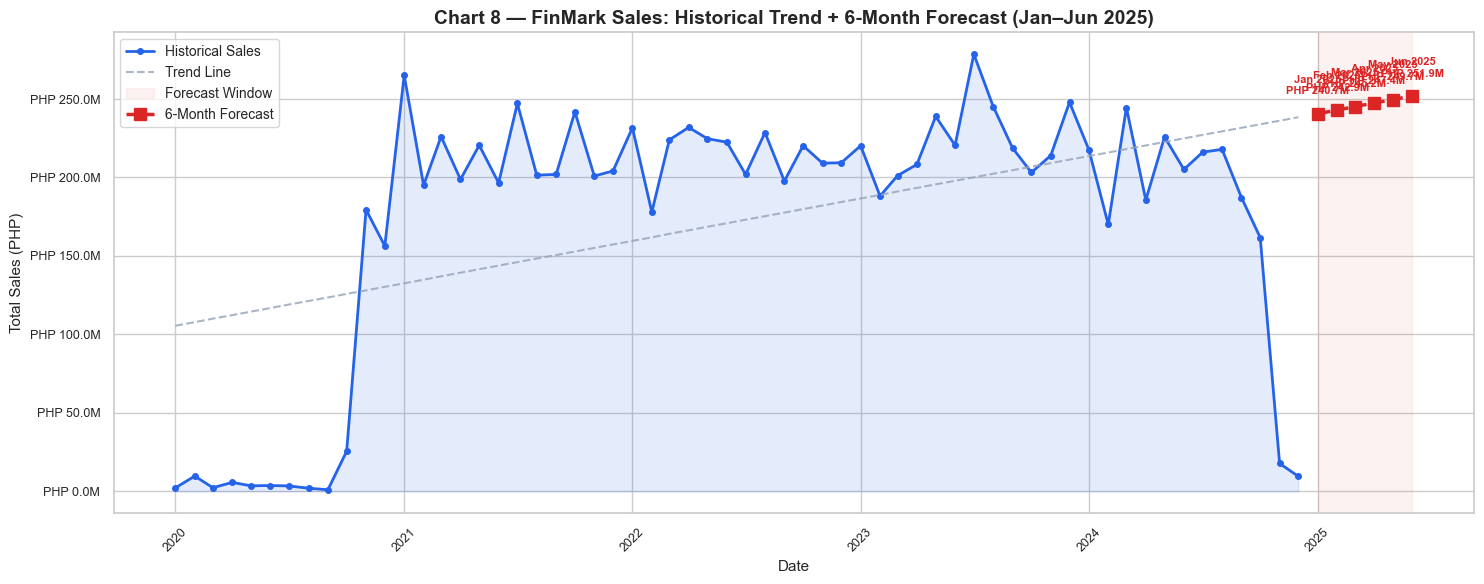

INTERPRETATION — Chart 8
-------------------------------------------------------
The model projects a continuing downward trend from Jan to
Jun 2025, driven by the 2024 decline. Monthly sales are
forecast between PHP 240.7M and PHP 251.9M.
Total projected 6-month revenue: PHP 1.48B.
Chart 8 saved.


In [15]:
# --- CHART 8: Historical Sales + 6-Month Forecast (Line Chart) ---

fig, ax = plt.subplots(figsize=(15, 6))
ax.fill_between(monthly['Date'], monthly['Total_Sales'],
                alpha=0.12, color=COLOR_MAIN)
ax.plot(monthly['Date'], monthly['Total_Sales'],
        color=COLOR_MAIN, linewidth=2, marker='o', markersize=4,
        label='Historical Sales')
ax.plot(monthly['Date'], y_fitted,
        color=COLOR_TREND, linewidth=1.5, linestyle='--', alpha=0.8,
        label='Trend Line')
ax.axvspan(future_dates[0], future_dates[-1],
           alpha=0.06, color=COLOR_FORECAST, label='Forecast Window')
ax.plot(future_dates, future_predictions,
        color=COLOR_FORECAST, linewidth=2.5, linestyle='--',
        marker='s', markersize=9, label='6-Month Forecast')
for date, val, label in zip(future_dates, future_predictions, future_labels):
    ax.annotate(f'{label}\nPHP {val/1e6:.1f}M',
                xy=(date, val), xytext=(0, 14),
                textcoords='offset points', ha='center',
                fontsize=8, color=COLOR_FORECAST, fontweight='bold')
ax.set_title('Chart 8 — FinMark Sales: Historical Trend + 6-Month Forecast (Jan–Jun 2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('m2_chart8_forecast_line.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 8')
print('-' * 55)
print(f'The model projects a continuing downward trend from Jan to')
print(f'Jun 2025, driven by the 2024 decline. Monthly sales are')
print(f'forecast between PHP {future_predictions.min()/1e6:.1f}M and PHP {future_predictions.max()/1e6:.1f}M.')
print(f'Total projected 6-month revenue: PHP {future_predictions.sum()/1e9:.2f}B.')
print('Chart 8 saved.')

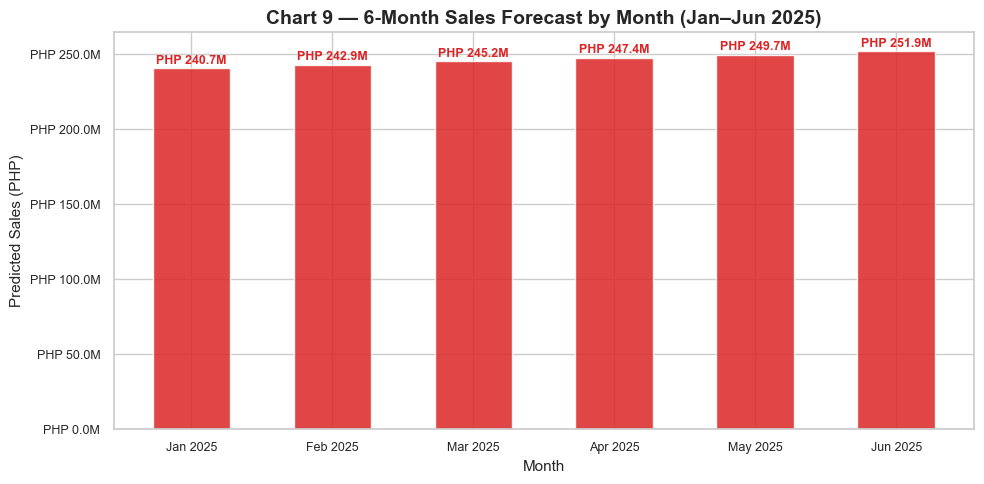

INTERPRETATION — Chart 9
-------------------------------------------------------
This bar chart gives stakeholders a clear month-by-month
view of expected sales for the first half of 2025.
The forecast shows a gradual decline across all 6 months,
with the highest projected month being Jan 2025
at PHP 240.7M and the lowest being Jun 2025
at PHP 251.9M.
Chart 9 saved.


In [16]:
# --- CHART 9: 6-Month Forecast Bar Chart ---
# A bar chart view of the forecast makes it easier for
# stakeholders to compare predicted values month by month.

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(future_labels, future_predictions,
              color=COLOR_FORECAST, edgecolor='white', width=0.55, alpha=0.85)
for bar, val in zip(bars, future_predictions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e6,
            f'PHP {val/1e6:.1f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=COLOR_FORECAST)
ax.set_title('Chart 9 — 6-Month Sales Forecast by Month (Jan–Jun 2025)')
ax.set_xlabel('Month')
ax.set_ylabel('Predicted Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('m2_chart9_forecast_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 9')
print('-' * 55)
print('This bar chart gives stakeholders a clear month-by-month')
print('view of expected sales for the first half of 2025.')
print(f'The forecast shows a gradual decline across all 6 months,')
print(f'with the highest projected month being {future_labels[0]}')
print(f'at PHP {future_predictions[0]/1e6:.1f}M and the lowest being {future_labels[-1]}')
print(f'at PHP {future_predictions[-1]/1e6:.1f}M.')
print('Chart 9 saved.')

In [17]:
# ============================================================
# STEP 9 — BUSINESS INSIGHTS SUMMARY
# ============================================================

print('=' * 60)
print('     FINMARK MILESTONE 2 — KEY FINDINGS & INSIGHTS')
print('=' * 60)
print('''
1. SALES TREND
   FinMark sales grew strongly from 2020-2021 and held stable
   through 2023. A -23.3% decline in 2024 is the most critical
   concern and drives the downward 6-month forecast.

2. SEASONALITY
   March, July, and August are peak months. Q3 is the strongest
   quarter. The 6-month forecast (Jan-Jun 2025) covers Q1 and
   Q2, including the expected March peak.

3. TOP PRODUCTS
   FinSphere Intelligence Suite, RevenueVue Dashboard, and
   ForecastXcelerator drive the most revenue. Protecting and
   growing these lines is essential to recovery.

4. PRICING STABILITY
   Revenue per unit has remained stable. The 2024 decline is
   volume-driven (fewer deals) not price-driven. A targeted
   customer acquisition and retention push could reverse it.

5. ROLLING AVERAGE INSIGHT
   The new Rolling_3M_Avg feature confirms purchasing trends
   are gradual. Short-term spikes in individual months do not
   signal lasting recovery — sustained effort is required.

6. FORECAST SUMMARY
   Projected 6-month total revenue: PHP {:.2f}B
   Monthly range: PHP {:.1f}M to PHP {:.1f}M
   Trend direction: Declining
   Recommended action: Customer acquisition drive in Q1 2025
   to capture the March seasonal peak.
'''.format(
    future_predictions.sum()/1e9,
    future_predictions.min()/1e6,
    future_predictions.max()/1e6
))
print('=' * 60)

     FINMARK MILESTONE 2 — KEY FINDINGS & INSIGHTS

1. SALES TREND
   FinMark sales grew strongly from 2020-2021 and held stable
   through 2023. A -23.3% decline in 2024 is the most critical
   concern and drives the downward 6-month forecast.

2. SEASONALITY
   March, July, and August are peak months. Q3 is the strongest
   quarter. The 6-month forecast (Jan-Jun 2025) covers Q1 and
   Q2, including the expected March peak.

3. TOP PRODUCTS
   FinSphere Intelligence Suite, RevenueVue Dashboard, and
   ForecastXcelerator drive the most revenue. Protecting and
   growing these lines is essential to recovery.

4. PRICING STABILITY
   Revenue per unit has remained stable. The 2024 decline is
   volume-driven (fewer deals) not price-driven. A targeted
   customer acquisition and retention push could reverse it.

5. ROLLING AVERAGE INSIGHT
   The new Rolling_3M_Avg feature confirms purchasing trends
   are gradual. Short-term spikes in individual months do not
   signal lasting recovery — s

In [18]:
# ============================================================
# STEP 10 — SAVE ALL OUTPUTS
# ============================================================

df.to_csv('transactions_featured_m2.csv', index=False)
forecast_df.to_csv('finmark_6month_forecast.csv', index=False)

print('All outputs saved to C:\\Users\\Matti\\Documents\\School')
print('')
print('Files saved:')
print('   transactions_featured_m2.csv  <- dataset with all features')
print('   finmark_6month_forecast.csv   <- 6-month sales forecast')
print('   m2_chart1_monthly_sales.png   <- monthly sales over time')
print('   m2_chart2_seasonal.png        <- seasonal pattern')
print('   m2_chart3_quarterly.png       <- sales by quarter')
print('   m2_chart4_yearly.png          <- annual sales + YoY growth')
print('   m2_chart5_products.png        <- top 10 products')
print('   m2_chart6_heatmap.png         <- correlation heatmap')
print('   m2_chart7_rpu.png             <- revenue per unit over time')
print('   m2_chart8_forecast_line.png   <- forecast line chart')
print('   m2_chart9_forecast_bar.png    <- forecast bar chart')

All outputs saved to C:\Users\Matti\Documents\School

Files saved:
   transactions_featured_m2.csv  <- dataset with all features
   finmark_6month_forecast.csv   <- 6-month sales forecast
   m2_chart1_monthly_sales.png   <- monthly sales over time
   m2_chart2_seasonal.png        <- seasonal pattern
   m2_chart3_quarterly.png       <- sales by quarter
   m2_chart4_yearly.png          <- annual sales + YoY growth
   m2_chart5_products.png        <- top 10 products
   m2_chart6_heatmap.png         <- correlation heatmap
   m2_chart7_rpu.png             <- revenue per unit over time
   m2_chart8_forecast_line.png   <- forecast line chart
   m2_chart9_forecast_bar.png    <- forecast bar chart
